In [35]:
import numpy as np
import random
import heapq
from deap import base, creator, tools, algorithms
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, mutual_info_score
from skimage.metrics import structural_similarity as SSIM

In [36]:
import scipy.io as sio
import numpy as np

import os
import scipy.io as sio

# Get the directory where the script is currently located
base_path = os.path.abspath(os.getcwd())
file_path = os.path.join(base_path, 'WHU-HIDS', 'Matlab_data_format', 'WHU-Hi-LongKou', 'WHU_Hi_LongKou.mat')

print(f"Looking for file at: {file_path}")
mat_data = sio.loadmat(file_path)
print(mat_data.keys()) 
# Replace 'WHU_Hi_LongKou' with the variable name found in step 2
images = mat_data['WHU_Hi_LongKou'] 
#Verify the shape (should be 1217, 303, 274)
print(f"Data Shape: {images.shape}")
np.save("images.npy", images)

##similarly for ground truth file
file_path = os.path.join(base_path, 'WHU-HIDS', 'Matlab_data_format', 'WHU-Hi-LongKou', 'WHU_Hi_LongKou_gt.mat')
print(f"Looking for file at: {file_path}")
mat_data = sio.loadmat(file_path)
print(mat_data.keys()) 
labels = mat_data['WHU_Hi_LongKou_gt'] 
print(f"Data Shape: {labels.shape}")
np.save("labels.npy", labels)

Looking for file at: C:\Users\rakes.LAPTOP-DHARMA-A\Desktop\VCE\2025-26\Evensem\Other\WHU-HIDS\Matlab_data_format\WHU-Hi-LongKou\WHU_Hi_LongKou.mat
dict_keys(['__header__', '__version__', '__globals__', 'WHU_Hi_LongKou'])
Data Shape: (550, 400, 270)
Looking for file at: C:\Users\rakes.LAPTOP-DHARMA-A\Desktop\VCE\2025-26\Evensem\Other\WHU-HIDS\Matlab_data_format\WHU-Hi-LongKou\WHU_Hi_LongKou_gt.mat
dict_keys(['__header__', '__version__', '__globals__', 'WHU_Hi_LongKou_gt'])
Data Shape: (550, 400)


In [37]:
# Load the dataset
image = np.load("images.npy")  # Hyperspectral data (550 × 400 × 270)
labels = np.load("labels.npy")  # Ground truth (550 × 400)
print(image.shape)
print(labels.shape)
num_bands = image.shape[-1] 
print(len(np.unique(labels)))
print(num_bands)

(550, 400, 270)
(550, 400)
10
270


In [38]:
#num_bands = 5 
selected_region = image[0:500, 0:500, 0:num_bands]
print(f"selected region:{selected_region.shape}")
nmi_matrix = np.zeros((num_bands, num_bands))
ssim_matrix = np.zeros((num_bands, num_bands))
dissimilarity_matrix = np.zeros((num_bands, num_bands))
print(num_bands)

selected region:(500, 400, 270)
270


In [39]:
import time
def calculate_entropy(data):
    _, counts = np.unique(data, return_counts=True)
    probabilities = counts / counts.sum()
    if len(probabilities) == 1:
        return 0
    return -np.sum(probabilities * np.log2(probabilities))

def discretize_band(band, num_bins=256):
    band_min = np.min(band)
    band_max = np.max(band)
    bins = np.linspace(band_min, band_max, num_bins)
    discrete_band = np.digitize(band, bins) - 1 
    return discrete_band

#calculate nmi, vi(dissmi), ssim
def calc_hybridsim_dissim_matrices():
    start_time = time.perf_counter()
    for i in range(num_bands):
        print(f"calculating sim/dissm metrics for band:{i}")
        for j in range(i + 1, num_bands):
            band_i = discretize_band(selected_region[:, :, i].flatten())
            band_j = discretize_band(selected_region[:, :, j].flatten())
            if len(np.unique(band_i)) > 1 and len(np.unique(band_j)) > 1:
                mi = mutual_info_score(band_i, band_j)
                h_i = calculate_entropy(band_i)
                h_j = calculate_entropy(band_j)
                if h_i > 0 and h_j > 0:
                    dissimilarity_matrix[i, j] = h_i + h_j - 2 * mi
                    dissimilarity_matrix[j, i] = dissimilarity_matrix[i, j]
                    nmi_matrix[i, j] = 2 * mi / (h_i + h_j)
                    nmi_matrix[j, i] = nmi_matrix[i, j]
                ssim_value = SSIM(
                    selected_region[:, :, i],
                    selected_region[:, :, j],
                    data_range=selected_region[:, :, i].max() - selected_region[:, :, i].min()
                )
                ssim_matrix[i, j] = ssim_value
                ssim_matrix[j, i] = ssim_value
    hybrid_similarity_matrix = nmi_matrix + ssim_matrix
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")
    print(f"Total execution time: {elapsed_time/60:.2f} minutes")
    return hybrid_similarity_matrix

#rankbands using sim/diss matrices
def rank_bands(sim_matrix, dis_matrix, num_bands_to_select=50):
    avg_similarity = np.nanmean(sim_matrix, axis=1)
    dissimilarity = np.nanmin(dis_matrix, axis=1)
    range_similarity = avg_similarity.max() - avg_similarity.min()
    range_dissimilarity = dissimilarity.max() - dissimilarity.min()
    normalized_similarity = (avg_similarity - avg_similarity.min()) / range_similarity if range_similarity != 0 else np.zeros_like(avg_similarity)
    normalized_dissimilarity = (dissimilarity - dissimilarity.min()) / range_dissimilarity if range_dissimilarity != 0 else np.zeros_like(dissimilarity)
    scores = normalized_similarity * normalized_dissimilarity
    ranked_indices = np.argsort(scores)[::-1]
    return ranked_indices[:num_bands_to_select]

#rank bands using hybrid metrics as weights in the graph
#nmi + ssim for similarity and vi for dissim
#weight of the node in a graph is alpha*hybridsim + (1-alpha)*dissim
def rank_bands_graph_reach(hybrid_sim_matrix, dissim_matrix, num_bands_to_select=50):
    """
    Ranks bands using the 'Weighted Reach' logic.
    Each band is a node in a complete graph. 
    The edge weight between band i and j is its hybrid affinity (hybridSim * Dis).
    """
    import numpy as np

    # 1. Compute the Adjacency Matrix (Hybrid Affinity Matrix)
    # This represents the strength of the relationship between every pair of bands
    # sim_matrix: How much they share (NMI/SSIM)
    # dis_matrix: How unique they are (Variation of Information)
    adj_matrix = hybrid_sim_matrix * dissim_matrix

    # 2. Clear self-loops (diagonal) so a band doesn't rank itself
    np.fill_diagonal(adj_matrix, 0)

    # 3. Calculate 'Weighted Reach' (Degree Centrality)
    # This is the sum of all outgoing weights for each band (row total)
    weighted_reach = np.sum(adj_matrix, axis=1)

    # 4. Normalize the Reach scores to [0, 1] for stability
    reach_min = weighted_reach.min()
    reach_max = weighted_reach.max()
    
    if reach_max - reach_min != 0:
        normalized_reach = (weighted_reach - reach_min) / (reach_max - reach_min)
    else:
        normalized_reach = np.zeros_like(weighted_reach)

    # 5. Sort indices by Reach in descending order (High Reach = Informational Hub)
    ranked_indices = np.argsort(normalized_reach)[::-1]

    # Return the top K candidates for Phase 2 (NSGA-II)
    print(f"final weight reach of each band:{normalized_reach}")
    return ranked_indices[:num_bands_to_select]

In [40]:
hybrid_similarity_matrix = calc_hybridsim_dissim_matrices()
num_bands_to_select = int(num_bands*0.3)
print(num_bands_to_select)
graph_ranked_bands = rank_bands_graph_reach(hybrid_similarity_matrix, dissimilarity_matrix, num_bands_to_select)
print(f"Top {num_bands_to_select} sr_nmivi_graph_ranked_bands using weighted graph Ranked Bands: {graph_ranked_bands}")

calculating sim/dissm metrics for band:0
calculating sim/dissm metrics for band:1
calculating sim/dissm metrics for band:2
calculating sim/dissm metrics for band:3
calculating sim/dissm metrics for band:4
calculating sim/dissm metrics for band:5
calculating sim/dissm metrics for band:6
calculating sim/dissm metrics for band:7
calculating sim/dissm metrics for band:8
calculating sim/dissm metrics for band:9
calculating sim/dissm metrics for band:10
calculating sim/dissm metrics for band:11
calculating sim/dissm metrics for band:12
calculating sim/dissm metrics for band:13
calculating sim/dissm metrics for band:14
calculating sim/dissm metrics for band:15
calculating sim/dissm metrics for band:16
calculating sim/dissm metrics for band:17
calculating sim/dissm metrics for band:18
calculating sim/dissm metrics for band:19
calculating sim/dissm metrics for band:20
calculating sim/dissm metrics for band:21
calculating sim/dissm metrics for band:22
calculating sim/dissm metrics for band:23
ca

calculating sim/dissm metrics for band:194
calculating sim/dissm metrics for band:195
calculating sim/dissm metrics for band:196
calculating sim/dissm metrics for band:197
calculating sim/dissm metrics for band:198
calculating sim/dissm metrics for band:199
calculating sim/dissm metrics for band:200
calculating sim/dissm metrics for band:201
calculating sim/dissm metrics for band:202
calculating sim/dissm metrics for band:203
calculating sim/dissm metrics for band:204
calculating sim/dissm metrics for band:205
calculating sim/dissm metrics for band:206
calculating sim/dissm metrics for band:207
calculating sim/dissm metrics for band:208
calculating sim/dissm metrics for band:209
calculating sim/dissm metrics for band:210
calculating sim/dissm metrics for band:211
calculating sim/dissm metrics for band:212
calculating sim/dissm metrics for band:213
calculating sim/dissm metrics for band:214
calculating sim/dissm metrics for band:215
calculating sim/dissm metrics for band:216
calculating

In [41]:
#mo_gsr_bs (multi-objective graph based similarity ranking band selection)
import numpy as np
import random
from deap import base, creator, tools, algorithms
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score

# --- Hyperparameters ---
POP_SIZE = 50   
N_GEN = 100     
SAMPLE_SIZE = 10000
#remove below
#POP_SIZE = 10   
#N_GEN = 10     
#SAMPLE_SIZE = 1000

MUTATION_RATE = 0.2
CROSSOVER_RATE = 0.7
MIN_BANDS = 8  
MAX_BANDS = 30  # Increased for a better Pareto curve
#MAX_BANDS = num_bands_to_select


# Step 1: Weighted Reach Ranking (Phase 1)
# Assuming 'graph_ranked_bands' is the output from our previous function
graph_ranked_bands = list(graph_ranked_bands) 

# --- DEAP Multi-Objective Setup ---
try:
    del creator.FitnessMulti
    del creator.Individual
except AttributeError:
    pass

# weights=(1.0, -1.0) -> Maximize Accuracy, Minimize Subset Size
creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

# Step 2: 80/20 Guided Initialization Logic
def init_individual(guiding_list, total_bands_count):
    num_selected = random.randint(MIN_BANDS, MAX_BANDS)
    # 80% chance to pick from top Hubs, 20% chance to pick purely random
    if random.random() < 0.8:
        # Use the hubs identified by Phase 1
        genes = random.sample(guiding_list, min(num_selected, len(guiding_list)))
        return creator.Individual(genes)
    else:
        # Pure exploration: pick from any band in the HSI
        genes = random.sample(range(total_bands_count), num_selected)
        return creator.Individual(genes)

toolbox = base.Toolbox()
# Pass the top hubs and the total band count (e.g., 274)
toolbox.register("individual", init_individual, graph_ranked_bands, num_bands)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- NSGA-II MOO Evaluation (Maximize Accuracy + minimize Subset Size) ---
def evaluate_multi(individual):
    if len(individual) == 0: return 0, 999
    
    selected_indices = list(set(individual)) # Ensure unique bands
    X = image.reshape(-1, num_bands)[:, selected_indices]
    y = labels.ravel()
    
    # Stratified Sampling for speed
    indices = np.random.choice(len(y), size=min(SAMPLE_SIZE, len(y)), replace=False)
    X, y = X[indices], y[indices]
    
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
        clf = SVC(kernel='rbf', C=100)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        # f1: composite accuracy metric
        # len(individual): subset size objective
        return acc, len(individual)
    except:
        return 0, 999

#Create unique subsets of bands to avoid redundancy
def create_unique_population(n, guiding_list, total_bands):
    population = []
    seen_individuals = set() # Stores 'frozensets' of band indices
    
    while len(population) < n:
        # Create an individual using our 80/20 logic
        ind = init_individual(guiding_list, total_bands)
        
        # Convert to a sorted tuple or frozenset for a 'uniqueness signature'
        signature = frozenset(ind)
        
        if signature not in seen_individuals:
            seen_individuals.add(signature)
            population.append(ind)
            
    return population

# Mutation: Replace one band while maintaining the length constraint
def mutate_unique(individual):
    if random.random() < MUTATION_RATE:
        idx_to_replace = random.randint(0, len(individual) - 1)
        available_bands = list(set(graph_ranked_bands) - set(individual))
        if available_bands:
            individual[idx_to_replace] = random.choice(available_bands)
    return (individual,)

# Crossover: Ensure the number of bands remains within constraints
def crossover_unique(parent1, parent2):
    crossover_point = random.randint(1, min(len(parent1), len(parent2)) - 1)
    
    child1_genes = list(set(parent1[:crossover_point] + parent2[crossover_point:]))
    child2_genes = list(set(parent2[:crossover_point] + parent1[crossover_point:]))

    # Ensure valid band count
    child1_genes = child1_genes[:MAX_BANDS] if len(child1_genes) > MAX_BANDS else child1_genes
    child2_genes = child2_genes[:MAX_BANDS] if len(child2_genes) > MAX_BANDS else child2_genes
    
    # Fill up to MIN_BANDS if needed
    while len(child1_genes) < MIN_BANDS:
        new_band = random.choice(graph_ranked_bands)
        if new_band not in child1_genes:
            child1_genes.append(new_band)
    
    while len(child2_genes) < MIN_BANDS:
        new_band = random.choice(graph_ranked_bands)
        if new_band not in child2_genes:
            child2_genes.append(new_band)

    return creator.Individual(child1_genes), creator.Individual(child2_genes)

# --- Evolutionary Operators ---
toolbox.register("evaluate", evaluate_multi)
#toolbox.register("mate", tools.cxTwoPoint) # Standard for NSGA-II
#toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
toolbox.register("mate", crossover_unique)
toolbox.register("mutate", mutate_unique)
toolbox.register("select", tools.selNSGA2) # NSGA-II Selection

# --- Execution ---
def run_mo_gsr_bs():
    # Start the timer
    start_time = time.perf_counter()
    #pop = toolbox.population(n=POP_SIZE)
    pop = create_unique_population(POP_SIZE, graph_ranked_bands, num_bands)    
    print(pop)
    
    # Pareto Front to store the non-dominated solutions
    pareto_front = tools.ParetoFront()
    
    # We use eaMuPlusLambda for better NSGA-II performance
    algorithms.eaMuPlusLambda(pop, toolbox, mu=POP_SIZE, lambda_=POP_SIZE, 
                              cxpb=CROSSOVER_RATE, mutpb=MUTATION_RATE, 
                              ngen=N_GEN, stats=None, halloffame=pareto_front, verbose=True)

    # End the timer
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")
    print(f"Total execution time: {elapsed_time/60:.2f} minutes")
    return pareto_front

# Get the Menu of optimal choices
optimal_front = run_mo_gsr_bs()

print("--- Pareto Optimal Subsets ---")
print(f"optimal_front:{optimal_front}")
for ind in optimal_front:
    print(f"Bands: {len(ind)},{ind} Accuracy: {ind.fitness.values[0]:.4f}")

[[np.int64(220), np.int64(141), np.int64(206), np.int64(223), np.int64(140), np.int64(265), np.int64(180), np.int64(194), np.int64(228), np.int64(193), np.int64(182), np.int64(222), np.int64(258), np.int64(181), np.int64(201), np.int64(189), np.int64(142), np.int64(149), np.int64(166), np.int64(263), np.int64(260), np.int64(196), np.int64(136), np.int64(156), np.int64(230), np.int64(163)], [np.int64(142), np.int64(200), np.int64(156), np.int64(154), np.int64(150), np.int64(194), np.int64(185), np.int64(138), np.int64(162), np.int64(193), np.int64(189), np.int64(167), np.int64(137), np.int64(197)], [np.int64(258), np.int64(187), np.int64(136), np.int64(224), np.int64(179), np.int64(191), np.int64(201), np.int64(156), np.int64(207), np.int64(221), np.int64(236), np.int64(194), np.int64(150), np.int64(147), np.int64(185), np.int64(203)], [217, 177, 70, 47, 108, 153, 63, 33, 90, 6, 48, 173, 150, 38], [np.int64(198), np.int64(220), np.int64(200), np.int64(191), np.int64(208), np.int64(196),

gen	nevals
0  	50    
1  	42    
2  	45    
3  	44    
4  	47    
5  	43    
6  	45    
7  	42    
8  	45    
9  	45    
10 	47    
11 	48    
12 	44    
13 	45    
14 	41    
15 	44    
16 	41    
17 	41    
18 	48    
19 	47    
20 	44    
21 	44    
22 	43    
23 	46    
24 	44    
25 	45    
26 	44    
27 	41    
28 	46    
29 	46    
30 	42    
31 	44    
32 	47    
33 	45    
34 	47    
35 	42    
36 	47    
37 	42    
38 	46    
39 	47    
40 	47    
41 	50    
42 	43    
43 	44    
44 	48    
45 	43    
46 	43    
47 	46    
48 	45    
49 	46    
50 	46    
51 	45    
52 	46    
53 	43    
54 	46    
55 	46    
56 	45    
57 	45    
58 	49    
59 	45    
60 	45    
61 	45    
62 	48    
63 	45    
64 	46    
65 	45    
66 	46    
67 	44    
68 	47    
69 	45    
70 	45    
71 	46    
72 	43    
73 	46    
74 	43    
75 	47    
76 	43    
77 	46    
78 	44    
79 	45    
80 	46    
81 	48    
82 	45    
83 	47    
84 	45    
85 	44    
86 	48    
87 	49    
88 	47    
89 	41    

In [45]:
#"The final optimal band subset is determined by identifying the 
#Knee Pointof the Pareto-optimal front. The Knee Point represents the 
#solution where the marginal gain in classification accuracy per additional
#spectral band significantly diminishes. By selecting this point, MO-GSR-BS
#objectively identifies the most compact and discriminative spectral manifold, 
#effectively balancing computational sparsity with predictive robustness."
def find_knee_point1(pareto_front):
    # Sort by number of bands
    sorted_front = sorted(pareto_front, key=lambda x: len(x))
    # Calculate the 'distance' to the Ideal Point (0 bands, 1.0 accuracy)
    # We normalize both values to 0-1 scale first
    best_knee = None
    min_dist = float('inf')
    for ind in sorted_front:
        acc = ind.fitness.values[0]
        size = len(ind) / MAX_BANDS # Normalized size
        
        # Distance to (0, 1) -> Lower is better
        dist = np.sqrt((1 - acc)**2 + (size)**2)
        if  dist < min_dist:
            min_dist = dist
            best_knee = ind
    return best_knee

def find_knee_point(optimal_front):
    sorted_individuals = sorted(optimal_front, key=lambda ind: len(ind))
    x_data = np.array([len(ind) for ind in optimal_front])
    y_data = np.array([ind.fitness.values[0] for ind in optimal_front])

    # 2. Sort by number of bands for a clean line plot
    sort_idx = np.argsort(x_data)
    x_sort = x_data[sort_idx]
    y_sort = y_data[sort_idx]

    # 3. Find Knee Point (Distance to Ideal Point Method)
    # Normalize to [0, 1] so scales don't bias the distance
    x_norm = (x_sort - x_sort.min()) / (x_sort.max() - x_sort.min())
    y_norm = (y_sort - y_sort.min()) / (y_sort.max() - y_sort.min())
    
    # Ideal point is (min_bands, max_accuracy) -> (0, 1) in normalized space
    distances = np.sqrt((x_norm - 0)**2 + (y_norm - 1)**2)
    knee_idx = np.argmin(distances)
    knee_x = x_sort[knee_idx]
    knee_y = y_sort[knee_idx]
    knee_individual = sorted_individuals[knee_idx]
    knee_bands = list(knee_individual) # This is your list of band indices
    return knee_bands

best_subset = find_knee_point(optimal_front)
print(f"Knee point of the pareto front len:{len(best_subset)}:{best_subset}")

Knee point of the pareto front len:15:[np.int64(258), np.int64(136), 8, 141, 48, np.int64(145), 208, 19, 85, 23, 184, 153, 58, np.int64(187), 125]


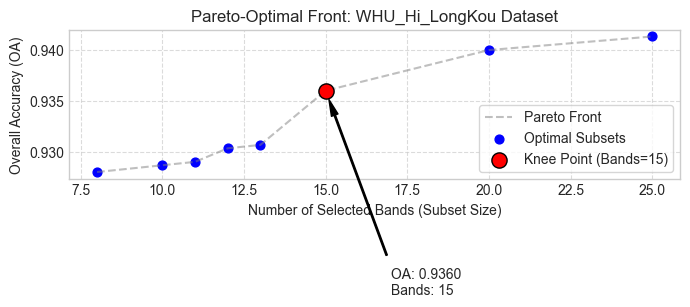

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pareto_with_knee(optimal_front, dataset_name="WHU_Hi_LongKou"):
    # 1. Extract data from DEAP Pareto Front
    # x = Number of bands, y = Accuracy
    x_data = np.array([len(ind) for ind in optimal_front])
    y_data = np.array([ind.fitness.values[0] for ind in optimal_front])

    # 2. Sort by number of bands for a clean line plot
    sort_idx = np.argsort(x_data)
    x_sort = x_data[sort_idx]
    y_sort = y_data[sort_idx]

    # 3. Find Knee Point (Distance to Ideal Point Method)
    # Normalize to [0, 1] so scales don't bias the distance
    x_norm = (x_sort - x_sort.min()) / (x_sort.max() - x_sort.min())
    y_norm = (y_sort - y_sort.min()) / (y_sort.max() - y_sort.min())
    
    # Ideal point is (min_bands, max_accuracy) -> (0, 1) in normalized space
    distances = np.sqrt((x_norm - 0)**2 + (y_norm - 1)**2)
    knee_idx = np.argmin(distances)
    
    knee_x = x_sort[knee_idx]
    knee_y = y_sort[knee_idx]

    # 4. Plotting (IEEE Style)
    plt.figure(figsize=(7, 5))
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Plot the full front
    plt.plot(x_sort, y_sort, '--', color='gray', alpha=0.5, label='Pareto Front')
    plt.scatter(x_sort, y_sort, color='blue', s=40, label='Optimal Subsets')
    
    # Highlight the Knee Point
    plt.scatter(knee_x, knee_y, color='red', s=120, edgecolors='black', 
                zorder=5, label=f'Knee Point (Bands={knee_x})')
    
    # Annotate the Knee
    plt.annotate(f'OA: {knee_y:.4f}\nBands: {knee_x}', 
                 xy=(knee_x, knee_y), xytext=(knee_x+2, knee_y-0.02),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    plt.title(f"Pareto-Optimal Front: {dataset_name} Dataset", fontsize=12)
    plt.xlabel("Number of Selected Bands (Subset Size)", fontsize=10)
    plt.ylabel("Overall Accuracy (OA)", fontsize=10)
    plt.legend(loc='lower right', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f"pareto_{dataset_name.lower()}.pdf", dpi=300) # Save as vector PDF
    plt.show()

# draw chart
plot_pareto_with_knee(optimal_front, "WHU_Hi_LongKou")

In [47]:
# Save Pareto front optimal subsets to file
import pickle
filename = "pareto_front_WHU_Hi_LongKou.pkl"
with open(filename, "wb") as f:
    # We convert to a list because ParetoFront is a special DEAP object
    pickle.dump(list(optimal_front), f)
print(f"Pareto Front stored successfully in {filename}")

Pareto Front stored successfully in pareto_front_WHU_Hi_LongKou.pkl


[[np.int64(258), np.int64(268), 8, 137, 141, 13, 19, 23, 153, 165, 167, 45, 48, 49, 85, 221, 101, 232, 107, 237, 113, 241, 118, 250, 124], [np.int64(258), np.int64(136), 8, 141, np.int64(145), 19, 23, 153, 165, 48, 184, 58, np.int64(187), 208, 85, 225, 237, 111, 243, 125], [np.int64(258), np.int64(136), 8, 141, 48, np.int64(145), 208, 19, 85, 23, 184, 153, 58, np.int64(187), 125], [131, 38, 167, np.int64(136), 8, 137, 141, 13, np.int64(184), 23, 153, 250, 124], [np.int64(258), 165, np.int64(136), 8, 141, 48, 241, 19, 148, np.int64(150), 118, 24], [np.int64(258), 165, np.int64(136), 8, 141, 48, 241, 19, 148, 250, 124], [np.int64(258), np.int64(136), 8, 141, np.int64(145), 19, 23, 153, 250, 124], [131, 38, 167, 137, 76, 150, 94, np.int64(223)]]


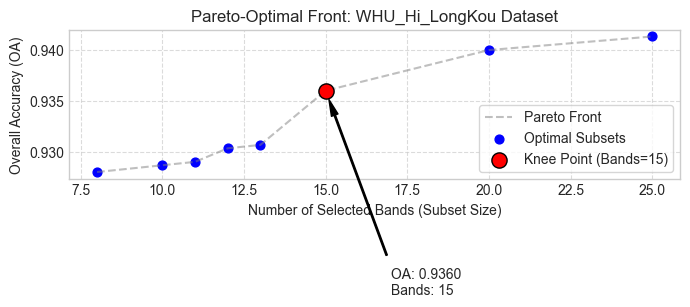

[np.int64(258), np.int64(136), 8, 141, 48, np.int64(145), 208, 19, 85, 23, 184, 153, 58, np.int64(187), 125]


In [51]:
# --- Pareto front optimal subsets from file ---
with open(filename, "rb") as f:
    loaded_front = pickle.load(f)
print(loaded_front)
find_knee_point(loaded_front)
plot_pareto_with_knee(loaded_front, "WHU_Hi_LongKou")
print(best_subset)

In [52]:
#cross-verify with RF and SVC classifiers
best_individual = best_subset
#selected_indices = list(best_individual) # Ensure unique bands
X = image.reshape(-1, num_bands)[:, best_individual]
y = labels.ravel()
print(best_individual[0])
print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
classifiers = {
    #"SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
}

start_time = time.perf_counter()
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    print(f"{name} - Accuracy: {acc:.4f}, Kappa: {kappa:.4f}, F1-score: {f1:.4f}")

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time:.2f} seconds")
print(f"Total execution time: {elapsed_time/60:.2f} minutes")

258
(220000, 15) (220000,)
Random Forest - Accuracy: 0.9410, Kappa: 0.9248, F1-score: 0.9383
Total execution time: 78.56 seconds
Total execution time: 1.31 minutes


In [ ]:
#Single Objective EA
labels_flat=labels.flatten()
sample_size=10000
import numpy as np
import random
from deap import base, creator, tools, algorithms
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score

POP_SIZE = 50   
N_GEN = 100     
MUTATION_RATE = 0.2
CROSSOVER_RATE = 0.7
MIN_BANDS = 3  
MAX_BANDS = 15 
sr_nmi_vi_ranked_bands = sr_nmi_vi_ranked_bands.tolist() if isinstance(sr_nmi_vi_ranked_bands, np.ndarray) else sr_nmi_vi_ranked_bands
try:
    del creator.FitnessMax
    del creator.Individual
except AttributeError:
    pass

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Initialize an individual with a random number of bands between MIN_BANDS and MAX_BANDS
def init_individual():
    num_selected_bands = random.randint(MIN_BANDS, MAX_BANDS)
    return creator.Individual(random.sample(sr_nmi_vi_ranked_bands, num_selected_bands))

toolbox = base.Toolbox()
toolbox.register("individual", init_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Mutation: Replace one band while maintaining the length constraint
def mutate_individual(individual):
    if random.random() < MUTATION_RATE:
        idx_to_replace = random.randint(0, len(individual) - 1)
        available_bands = list(set(sr_nmi_vi_ranked_bands) - set(individual))
        if available_bands:
            individual[idx_to_replace] = random.choice(available_bands)
    return (individual,)

# Crossover: Ensure the number of bands remains within constraints
def crossover(parent1, parent2):
    crossover_point = random.randint(1, min(len(parent1), len(parent2)) - 1)
    
    child1_genes = list(set(parent1[:crossover_point] + parent2[crossover_point:]))
    child2_genes = list(set(parent2[:crossover_point] + parent1[crossover_point:]))

    # Ensure valid band count
    child1_genes = child1_genes[:MAX_BANDS] if len(child1_genes) > MAX_BANDS else child1_genes
    child2_genes = child2_genes[:MAX_BANDS] if len(child2_genes) > MAX_BANDS else child2_genes
    
    # Fill up to MIN_BANDS if needed
    while len(child1_genes) < MIN_BANDS:
        new_band = random.choice(sr_nmi_vi_ranked_bands)
        if new_band not in child1_genes:
            child1_genes.append(new_band)
    
    while len(child2_genes) < MIN_BANDS:
        new_band = random.choice(sr_nmi_vi_ranked_bands)
        if new_band not in child2_genes:
            child2_genes.append(new_band)

    return creator.Individual(child1_genes), creator.Individual(child2_genes)

# Fitness function using SVM classification
def evaluate(individual):
    selected_indices = list(individual)
    X = image.reshape(-1, num_bands)[:, selected_indices]
    y = labels.ravel()
    random_indices = np.random.choice(len(labels_flat), size=sample_size, replace=False)
    X = X[random_indices, :]
    y = y[random_indices]
    unique_classes = np.unique(y)
    if len(unique_classes) < 2:
        return (0,)  

    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    if len(np.unique(y_train)) < 2:
        return (0,)
    
    clf = SVC()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    return (acc + kappa + f1,)

toolbox.register("mate", crossover)
toolbox.register("mutate", mutate_individual)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Run Genetic Algorithm
def run_ga():
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.HallOfFame(1)  
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", np.max)
    
    algorithms.eaSimple(pop, toolbox, cxpb=CROSSOVER_RATE, mutpb=MUTATION_RATE, 
                        ngen=N_GEN, stats=stats, halloffame=hof, verbose=True)

    return hof[0]  

best_individual = run_ga()
print(f"Optimized Bands (GA-Wrapped SR-NMI-VI): {best_individual}")

In [ ]:
Decision Tree - Accuracy: 0.8983, Kappa: 0.8711, F1-score: 0.8988
Naïve Bayes - Accuracy: 0.6409, Kappa: 0.5683, F1-score: 0.6606
SVM - Accuracy: 0.9096, Kappa: 0.8843, F1-score: 0.9020
Random Forest - Accuracy: 0.9359, Kappa: 0.9183, F1-score: 0.9332

In [ ]:
Decision Tree - Accuracy: 0.8981, Kappa: 0.8708, F1-score: 0.8987
Naïve Bayes - Accuracy: 0.6233, Kappa: 0.5510, F1-score: 0.6467
SVM - Accuracy: 0.9147, Kappa: 0.8908, F1-score: 0.9074
Random Forest - Accuracy: 0.9379, Kappa: 0.9209, F1-score: 0.9351